In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Statystyka - raport 

## Cel raportu 
Celem niniejszego raportu jest analiza danych o spóźnieniach pociągów spółki PKP Intercity z lat 2019 oraz 2020 zebranych ze strony: [link](https://dane.utk.gov.pl/) . Zamierzamy porównać jaką proporcje w każdej stacji stanowią spóźnione pociągi oraz jak sie ma stosunek spóźnionych pociągów z jednej stacji do wszystkich zatrzymań pociągów w danym roku. 

Zamierzamy również wykorzystać dane z GUS'U dotyczące ludności miast i miejscowości w Polsce do tego aby sprawdzić jakie stacje mają najwięcej spóźnień w stosunku do liczby mieszkańców w danej miejscowości. 

## Wstęp 
### Dane
Dane **PKP Intercity** które będziemy analizować obejmują:
- liczbę zatrzymań pociągów opóźnionych od 6min w zależności od konkretnego miesiąca,
- liczbę zatrzymań wszystkich pociągów w zależności od konkretnego miesiąca,
- wielkość opóźnień (w minutach) dla pociągów opóźnionych od 6min.
- procent opóźnionych zatrzymań na stacjach (rocznie)
- średni czas opóźnień na stacji dla pociągów opóźnionych od 6min

Dodatkowo połączyliśmy dane PKP z danymi z gusu wiążąc wielkość spóźnień z wielkościom populacji miasta. Niestety połączenie tych dwóch baz danych było skomplikowanym zadaniem i stacji przypisanych do konkretnych miejscowości jest ok. 60%. Na potrzeby naszej analizy będziemy korzystać z tego pomniejszonego zbioru danych, jednakże zdajemy sobie sprawę, że analiza tego typu danych może być wybrakowana. Dzięki temu możemy podzielić nasze stacje na te które należą do dużych miast (+100k mieszkańców) oraz należące do mniejszych miejscowości (<100k mieszkańców). 

### Co chcemy zbadać?
Chcemy porównać zbióry danych z 2019, 2020 dla dużych miast i małych miejscowości pod kątem:
-  prawdopodobieństwa spóźnienia pociągu (prawd_na_spoznienie_kazda_stacja_oddzielnie w prawd_pociagow)
- średnie roczne opóźnienie przypadające na jeden opóźniony pociąg (roczna_srednia_ile_spoznienia_na_pociag)
    policzmy do tego miary rozproszenia od średniej - odchylenie stand, kurtoza, skosnosc - mozna = porównać z danymi z pojedynczych stacji, 
    mniej wrażliwe na fluktuacje miesięczne
- histogramy tych cech, oraz wykresy pudelkowe 
- dystrybuanta empiryczna dla posortowanych danych względem wielkości miasta (dla danych)

## prawdopodobienstwo_pociagow_2019

rocznie_ile_pociagow_spoznionych_do_wszystkich_spoznionych - jaki procent spóźnionych pociągów ogólem stanowią pociągi z tej stacji w 2019
prawdopodobienstwo_na_spoznienie_kazda_stacja_oddzielnie - jakie jest prawdopodobieństwo spóznienia na konkretną stację 


In [52]:
prawd_pociagow_2019 = pd.read_excel('wyniki\prawd_pociagow_2019.xlsx')

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\karol\AppData\Local\Temp\ipykernel_16648\3538297125.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  prawd_pociagow_2019 = pd.read_excel('wyniki\prawd_pociagow_2019.xlsx')


## prawdopodobienstwo_pociagow_2020

In [53]:
prawd_pociagow_2020 = pd.read_excel('wyniki\prawd_pociagow_2020.xlsx')

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\karol\AppData\Local\Temp\ipykernel_16648\3659063272.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  prawd_pociagow_2020 = pd.read_excel('wyniki\prawd_pociagow_2020.xlsx')


## Prawdopodobieństwo spóźnienia pociągu rok 2019


In [54]:
prawd_pociagow_2019 = prawd_pociagow_2019.sort_values(by='prawd_na_spoznienie_kazda_stacja_oddzielnie', ascending=False)
#print(prawd_pociagow_2019.head(5))
print(prawd_pociagow_2019.iloc[[ i for i in range(10) ]][["Miasto", "prawd_na_spoznienie_kazda_stacja_oddzielnie"]])

            Miasto  prawd_na_spoznienie_kazda_stacja_oddzielnie
1288     Tereszpol                                     0.352826
1243  Zduńska Wola                                     0.348023
1149    Inowrocław                                     0.337028
316      Szamotuły                                     0.334089
1287      Biłgoraj                                     0.333014
317         Wronki                                     0.299522
501         Poznań                                     0.298692
1265   Zwierzyniec                                     0.296720
500     Rokietnica                                     0.295632
930      Nowa Ruda                                     0.292136


35 % szansy na spoźnienie mają te stacje - 

Porónajmy teraz histogramy dla małych i dużych miejscowości

297
1091


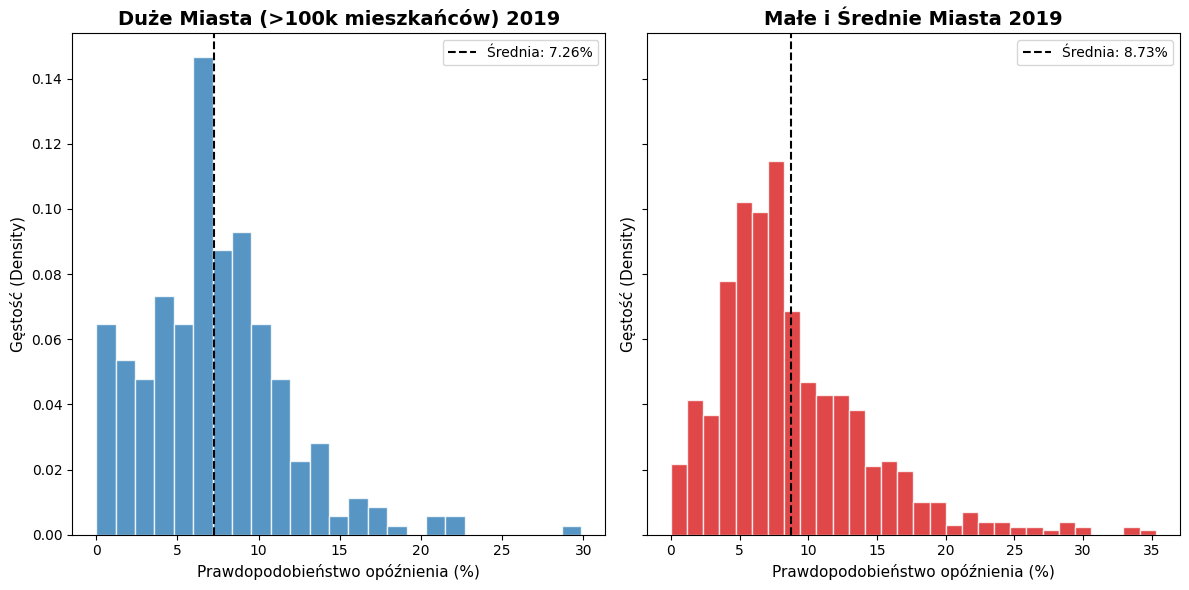

288
1092


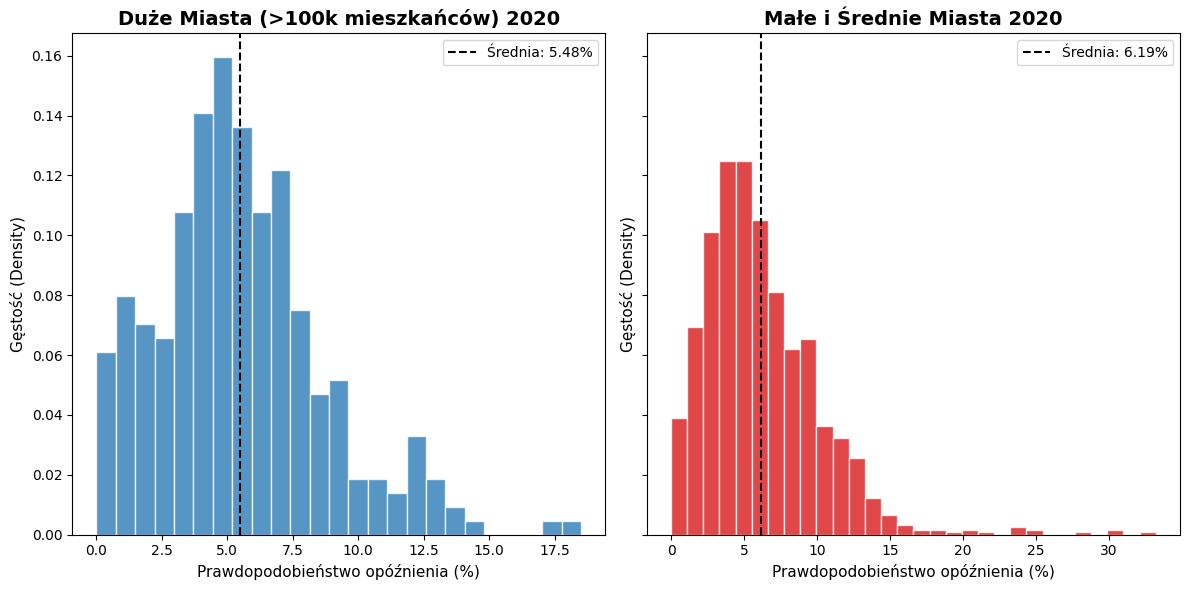

In [117]:
#2019
mask = prawd_pociagow_2019['Ludność'] > 100000
duze_miasta_2019 = prawd_pociagow_2019[mask]
male_miasta_2019 = prawd_pociagow_2019[~mask]

duze_miasta_spoz_2019 = duze_miasta_2019['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
male_miasta_spoz_2019 = male_miasta_2019['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
print(len(duze_miasta_spoz_2019))
print(len(male_miasta_spoz_2019))
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(duze_miasta_spoz_2019, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0].set_title('Duże Miasta (>100k mieszkańców) 2019', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[0].set_ylabel('Gęstość (Density)', fontsize=11)

ax[1].hist(male_miasta_spoz_2019, bins=30, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1].set_title('Małe i Średnie Miasta 2019', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[1].set_ylabel('Gęstość (Density)', fontsize=11)

ax[0].axvline(duze_miasta_spoz_2019.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_spoz_2019.mean():.2f}%')
ax[1].axvline(male_miasta_spoz_2019.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_spoz_2019.mean():.2f}%')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

# 2020
mask = prawd_pociagow_2020['Ludność'] > 100000
duze_miasta_2020 = prawd_pociagow_2020[mask]
male_miasta_2020 = prawd_pociagow_2020[~mask]

duze_miasta_spoz_2020 = duze_miasta_2020['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
male_miasta_spoz_2020 = male_miasta_2020['prawd_na_spoznienie_kazda_stacja_oddzielnie'] * 100
print(len(duze_miasta_spoz_2020))
print(len(male_miasta_spoz_2020))
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(duze_miasta_spoz_2020, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0].set_title('Duże Miasta (>100k mieszkańców) 2020', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[0].set_ylabel('Gęstość (Density)', fontsize=11)

ax[1].hist(male_miasta_spoz_2020, bins=30, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1].set_title('Małe i Średnie Miasta 2020', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
ax[1].set_ylabel('Gęstość (Density)', fontsize=11)

ax[0].axvline(duze_miasta_spoz_2020.mean(), color='black', linestyle='--', label=f'Średnia: {duze_miasta_spoz_2020.mean():.2f}%')
ax[1].axvline(male_miasta_spoz_2020.mean(), color='black', linestyle='--', label=f'Średnia: {male_miasta_spoz_2020.mean():.2f}%')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

dla Z wykresów widać, że prawdopodobienstwo spóźnienia dla dużych stacji jest niższe  o czym świadczy średnia o wynosząca 7.26%, z kolei dla mniejszych miast wynosi ona 8.73. Warto zauważyć, że histogram dla małych miast posiada dużo cięższy ogon niż w przypadku dużych miast. Jest to z pewnie spowodowane tym, że rzadziej kursują pociągi a stad wynika że nawet jeśli kilka z nich jest spóźnionych to wpływa to istotnie na analize. Kiedy porównamy ze sobą oba lata uwiadcznia się dużo lżejszy ogon w roku 2020 w stosunku do 2019. Widać również, że zakres danych zmniejszył się istotnie z 0-29 do 0-17.5. Konsekwentnie średnia spadła dla małych oraz średnich miast. 

In [118]:
prawd_pociagow_2019 = prawd_pociagow_2019.sort_values(by='prawd_na_spoznienie_kazda_stacja_oddzielnie', ascending=False)
#print(prawd_pociagow_2019.head(5))
print(prawd_pociagow_2019.iloc[[ i for i in range(30) ]][["Miasto", "Ludność", "prawd_na_spoznienie_kazda_stacja_oddzielnie"]])

prawd_pociagow_2020= prawd_pociagow_2020.sort_values(by='prawd_na_spoznienie_kazda_stacja_oddzielnie', ascending=False)
#print(prawd_pociagow_2019.head(5))
print(prawd_pociagow_2020.iloc[[ i for i in range(30) ]][["Miasto", "prawd_na_spoznienie_kazda_stacja_oddzielnie"]])

                 Miasto  Ludność  prawd_na_spoznienie_kazda_stacja_oddzielnie
1288          Tereszpol     3878                                     0.352826
1243       Zduńska Wola    53884                                     0.348023
1149         Inowrocław    84386                                     0.337028
316           Szamotuły    30251                                     0.334089
1287           Biłgoraj    39684                                     0.333014
317              Wronki    19074                                     0.299522
501              Poznań   534813                                     0.298692
1265        Zwierzyniec     6694                                     0.296720
500          Rokietnica    22986                                     0.295632
930           Nowa Ruda    33454                                     0.292136
931           Nowa Ruda    33454                                     0.288806
873     Radzyń Podlaski    23728                                

Policzmy teraz inne statystyki dla tego rozkładu: Odchylenie standardowe, skewness i kurthoze

In [ ]:
# Łączymy wyniki describe() w poziomie (axis=1)

extra_2019 = pd.Series({
    'Skewness': duze_miasta_spoz_2019.skew(),
    "Kurtosis": duze_miasta_spoz_2019.kurtosis()})
extra_2020 = pd.Series({
    'Skewness': duze_miasta_spoz_2020.skew(),
    "Kurtosis": duze_miasta_spoz_2020.kurtosis()})
duze_miasta_2019_stats = pd.concat([duze_miasta_spoz_2019.describe(), extra_2019])
duze_miasta_2020_stats = pd.concat([duze_miasta_spoz_2020.describe(), extra_2020])
porownanie = pd.concat([
    duze_miasta_2019_stats, 
    duze_miasta_2020_stats
], axis=1)

# Nadajemy własne nazwy kolumnom, żeby wiedzieć, który rok jest który
porownanie.columns = ['2019 (Duże miasta)', '2020 (Duże miasta)']

print(porownanie)
print("")
extra_2019 = pd.Series({
    'Skewness': male_miasta_spoz_2019.skew(),
    "Kurtosis": male_miasta_spoz_2019.kurtosis()})
extra_2020 = pd.Series({
    'Skewness': male_miasta_spoz_2020.skew(),
    "Kurtosis": male_miasta_spoz_2020.kurtosis()})
male_miasta_2019_stats = pd.concat([male_miasta_spoz_2019.describe(), extra_2019]) 
male_miasta_2020_stats = pd.concat([male_miasta_spoz_2020.describe(), extra_2020])
porownanie_male = pd.concat([  male_miasta_2019_stats, male_miasta_2020_stats], axis=1)
porownanie_male.columns = ['2019 (Małe i średnie miasta)', '2020 (Małe i średnie miasta)']
print(porownanie_male)

          2019 (Duże miasta)  2020 (Duże miasta)
count             297.000000          288.000000
mean                7.259211            5.476590
std                 4.365427            3.197537
min                 0.000000            0.000000
25%                 4.317678            3.429624
50%                 6.779985            5.053579
75%                 9.535304            7.146237
max                29.869213           18.507085
Skewness            1.012769            0.841641
Kurtosis            2.706796            1.117613

          2019 (Małe i średnie miasta)  2020 (Małe i średnie miasta)
count                      1091.000000                   1092.000000
mean                          8.725471                      6.191307
std                           5.510317                      4.012397
min                           0.000000                      0.000000
25%                           5.114871                      3.487477
50%                           7.548920        

Statystyki potwierdzają wnioski z histogramu. Małe miasta mają wyższe rozproszenie danych mierzone odchyleniem standardowym. Oba zbiory danych są prawostronnie skośne o czym świadczy dodatnia skośność. Pandas stosuje definicję Fishera kurtozy (rozklad normalny ==0) stąd nasz rozkład ma istotnie cięższe ogony od rozkładu normalnego. 
Kiedy porównujemy zbiory rok do roku rzuca nam się w oczy że dla stacji w małych i średnich miastach pomimo spadku średniej wzrosła kurtoza oraz skośność, co oznacza że średnio pociągi miały mniej spóźnień natomiast nie weliminowało to problemu niektórych stacji gdzie spóźnienia występowały bardzo często ( 30% szansy).

W 2020 roku zanotowano również spadek liczby łącznej zatrzymań na stacjach o 1 295 336 (ok. 4,6%, obliczenia własne na podstawie danych PKP) co zapewne mogłobyć spowodowane panemią koronawirusa i mogło odciążyć niektóre stacje a co za tym idzie zniwelować spóźnienia. 

In [124]:
#28182475

#26887139

print(28182475 - 26887139)
print((28182475 - 26887139) / 28182475 * 100)

1295336
4.596246426192164


#### Box-plot 

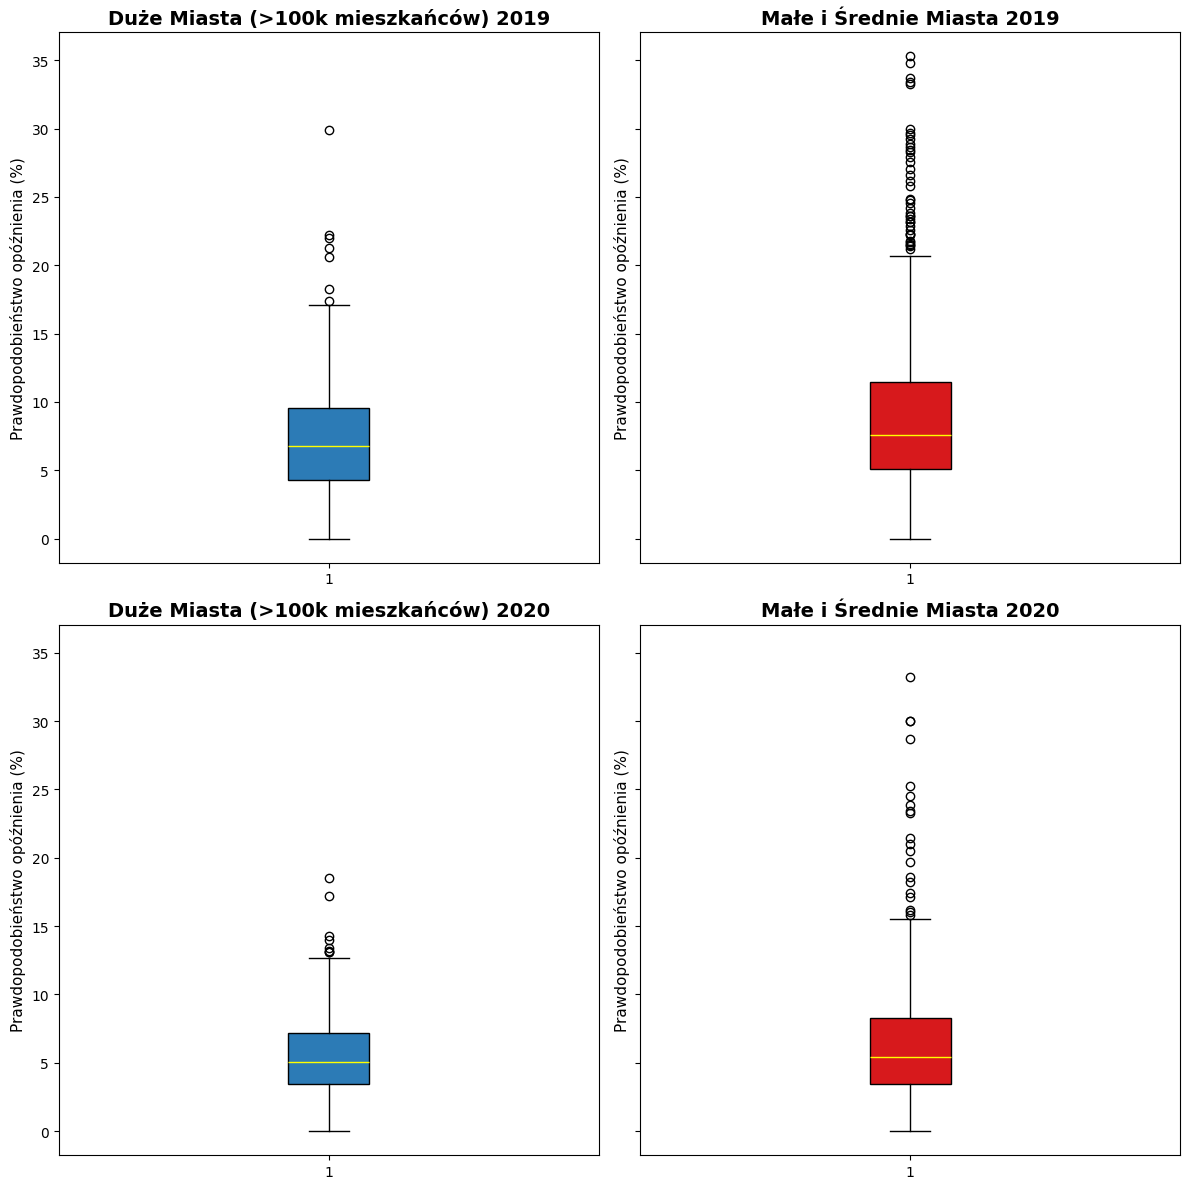

In [131]:
fig, ax = plt.subplots(2,2, figsize=(12,12), sharey=True)
ax[0,0].boxplot(duze_miasta_spoz_2019, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[0,0].set_title('Duże Miasta (>100k mieszkańców) 2019', fontsize=14, fontweight='bold')
ax[0,0].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[0,1].boxplot(male_miasta_spoz_2019, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[0,1].set_title('Małe i Średnie Miasta 2019', fontsize=14, fontweight='bold')
ax[0,1].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[1,0].boxplot(duze_miasta_spoz_2020, patch_artist=True, boxprops=dict(facecolor='#2c7bb6', color='black'), medianprops=dict(color='yellow'))
ax[1,0].set_title('Duże Miasta (>100k mieszkańców) 2020', fontsize=14, fontweight='bold')
ax[1,0].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)

ax[1,1].boxplot(male_miasta_spoz_2020, patch_artist=True, boxprops=dict(facecolor='#d7191c', color='black'), medianprops=dict(color='yellow'))
ax[1,1].set_title('Małe i Średnie Miasta 2020', fontsize=14, fontweight='bold')
ax[1,1].set_ylabel('Prawdopodobieństwo opóźnienia (%)', fontsize=11)
plt.tight_layout()
plt.show()

Sraken pierdaken opis box plotu co na nim widzimy - w sumie to samo co na histogramie

Widać że w 2020 roku oba rozkładu cechują szybciej zanikające ogony 

### Średnia wielkość opóźnienia w minutach
Bierzemy dla każdej stacji i każdego miesiąca sumę minut opóźnień i dzielimy przez liczbę opóźnionych pociągów + 1 zeby uniknąć dzielenia przez 0. 

In [140]:
duze_miasta_20 = pd.read_excel(r'wyniki\miasta_2020_wiecej_niz_100k.xlsx')
duze_miasta_20 = duze_miasta_20.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)
male_miasta_20 = pd.read_excel(r'wyniki\miasta_2020_mniej_niz_100k.xlsx')
male_miasta_20 = male_miasta_20.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)

duze_miasta_19 = pd.read_excel(r'wyniki\miasta_2019_wiecej_niz_100k.xlsx')
duze_miasta_19 = duze_miasta_19.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)
male_miasta_19 = pd.read_excel(r'wyniki\miasta_2019_mniej_niz_100k.xlsx')
male_miasta_19 = male_miasta_19.sort_values(by='roczna_srednia_ile_spoznienia_na_pociag', ascending=False)


duze_miasta_wielk_spoz_20=duze_miasta_20["roczna_srednia_ile_spoznienia_na_pociag"]
male_miasta_wielk_spoz_20=male_miasta_20["roczna_srednia_ile_spoznienia_na_pociag"]
duze_miasta_wielk_spoz_19=duze_miasta_19["roczna_srednia_ile_spoznienia_na_pociag"]
male_miasta_wielk_spoz_19=male_miasta_19["roczna_srednia_ile_spoznienia_na_pociag"]


print(male_miasta_wielk_spoz_20.head())
print(duze_miasta_20.iloc[[ i for i in range(10) ]][["Miasto", "roczna_srednia_ile_spoznienia_na_pociag"]])
print("------")
print(male_miasta_20.iloc[[ i for i in range(10) ]][["Miasto", "roczna_srednia_ile_spoznienia_na_pociag"]])


758    32
163    32
803    31
329    30
157    29
Name: roczna_srednia_ile_spoznienia_na_pociag, dtype: int64
        Miasto  roczna_srednia_ile_spoznienia_na_pociag
146   Koszalin                                       28
239  Białystok                                       27
231      Płock                                       24
35    Szczecin                                       23
101  Białystok                                       23
222      Płock                                       23
36      Gdańsk                                       23
10      Poznań                                       22
227   Szczecin                                       21
6       Gdynia                                       21
------
               Miasto  roczna_srednia_ile_spoznienia_na_pociag
758            Dygowo                                       32
163         Kołobrzeg                                       32
803  Ustronie Morskie                                       31
329       Świno

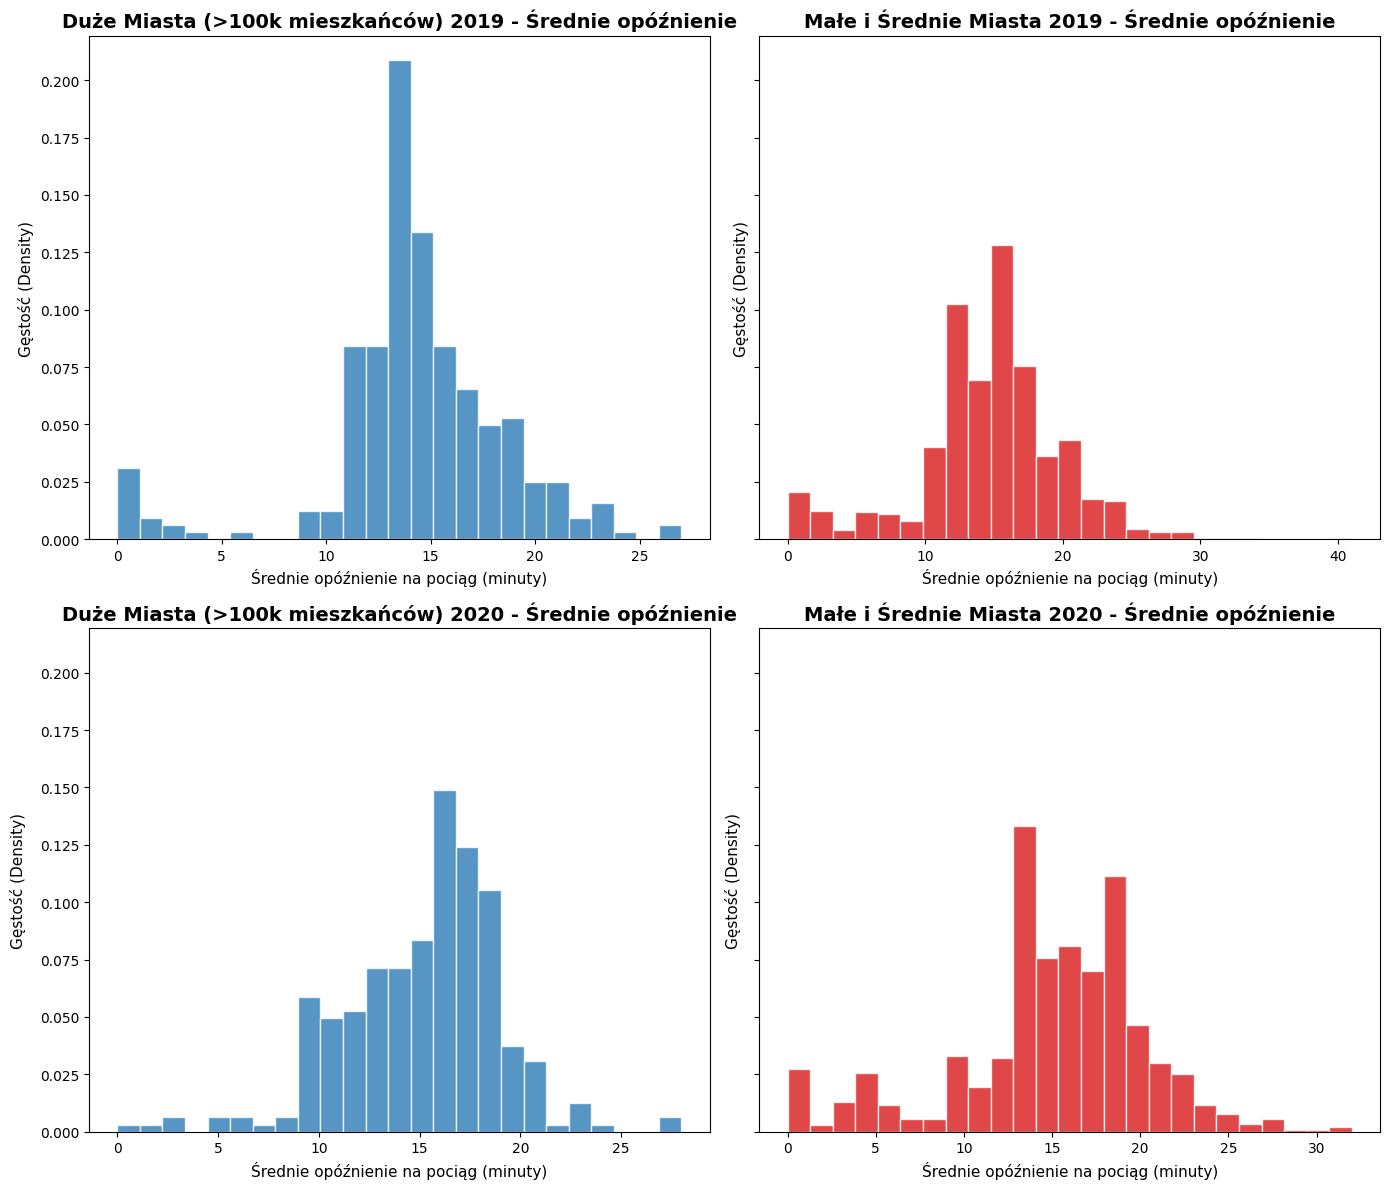

In [144]:
fig, ax = plt.subplots(2,2, figsize=(14,12), sharey=True)

ax[0,0].hist(duze_miasta_wielk_spoz_19, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[0,0].set_title('Duże Miasta (>100k mieszkańców) 2019 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[0,0].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[0,0].set_ylabel('Gęstość (Density)', fontsize=11)

ax[0,1].hist(male_miasta_wielk_spoz_19, bins=25, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[0,1].set_title('Małe i Średnie Miasta 2019 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[0,1].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[0,1].set_ylabel('Gęstość (Density)', fontsize=11)

ax[1,0].hist(duze_miasta_wielk_spoz_20, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.8, density=True)
ax[1,0].set_title('Duże Miasta (>100k mieszkańców) 2020 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[1,0].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[1,0].set_ylabel('Gęstość (Density)', fontsize=11, labelpad=10)

ax[1,1].hist(male_miasta_wielk_spoz_20, bins=25, color='#d7191c', edgecolor='white', alpha=0.8, density=True)
ax[1,1].set_title('Małe i Średnie Miasta 2020 - Średnie opóźnienie', fontsize=14, fontweight='bold')
ax[1,1].set_xlabel('Średnie opóźnienie na pociąg (minuty)', fontsize=11)
ax[1,1].set_ylabel('Gęstość (Density)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()
